# Video Game Sales Analysis Project
## Project Overview

In this project, I will analyze video game sales data to identify patterns that determine a game's success. Working as an analyst for the online store Ice, I will use this information to help plan future advertising campaigns.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import numpy as np

## Step 1: Loading and Initial Data Exploration

In [2]:
games = pd.read_csv('games.csv')

In [3]:
games.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [4]:
games.duplicated().any()

np.False_

### Key Questions to Answer:
- What's the total number of records in our dataset? There are 11,559 unique games in our dataset
- What data types are present in each column? I have 2 main datatypes, object (text-based), and float64 (decimal numbers)
- Are there any obvious issues with the data? Some obvious issues in the data are missing review data, inconsisitent data types, and temporal data gaps
- Do we see any immediate patterns or anomalies? In the data volume patterns, when I was finding out how many unique games there were, I had 16,715 total records but only 11,559 unique games suggesting some games appear multiple times (likely across different platforms/regions). Also, data type inconsistencies where columns did not have the right datatypes, and missing data anomolies

## Step 2: Data Preparation

### 2.1 Standardizing Column Names

In [5]:
games.columns = games.columns.str.lower()

### 2.2 Data Type Conversion

In [6]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [7]:
games['year_of_release'] = games['year_of_release'].astype('Int64')
games['user_score'] = pd.to_numeric(games['user_score'], errors = 'coerce')

In the column 'year_of_release', it was coming up as a float. When referencing a year, it never has decimals, so I converted it to Int64 which makes it a whole number.
In the column 'user_score', it was coming up as an object, so I changed it to_numeric, since scores should only be numbers.

# Pay attention to the abbreviation TBD (to be determined). Specify how you intend to handle such cases.
I have already fixed the 'tbd' portions of my DF when I converted my 'user_score' to_numeric. It was the only column that included 'tbd'.


In [8]:
games.isin(['tbd']).sum()

name               0
platform           0
year_of_release    0
genre              0
na_sales           0
eu_sales           0
jp_sales           0
other_sales        0
critic_score       0
user_score         0
rating             0
dtype: Int64

### 2.3 Handling Missing Values

In [9]:
games.isnull().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

In [10]:
missing_percent = (games.isnull().sum() / len(games)) * 100
missing_data = pd.DataFrame({
    'Missing Count': games.isnull().sum(),
    'Percentage': missing_percent
})
missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values('Missing Count', ascending = False)
print(missing_data)

                 Missing Count  Percentage
user_score                9125   54.591684
critic_score              8578   51.319174
rating                    6766   40.478612
year_of_release            269    1.609333
name                         2    0.011965
genre                        2    0.011965


In [11]:
games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']
missing_analysis = games.isnull().sum()
games['missing_count'] = games.isnull().sum(axis=1)
multiple_missing = games[games['missing_count'] >= 2]
high_missing = games[games['missing_count'] >= 3]
games['critic_score_missing'] = games['critic_score'].isnull()
missing_by_year = games.groupby('year_of_release')['critic_score_missing'].mean()
games['has_critic_score'] = games['critic_score'].notnull()
print("\nAverage total sales:")
print("Games WITH critic scores:", games[games['has_critic_score']]['total_sales'].mean())
print("Games WITHOUT critic scores:", games[~games['has_critic_score']]['total_sales'].mean())
print("Percentage of missing critic scores by year:")
print(missing_by_year.tail(10))
print("Missing values per column:")
print(missing_analysis[missing_analysis > 0])
print(f"Rows with 2+ missing values: {len(multiple_missing)}")
print(f"Rows with 3+ missing values: {len(high_missing)}")



Average total sales:
Games WITH critic scores: 0.68875384048175
Games WITHOUT critic scores: 0.3860247143856377
Percentage of missing critic scores by year:
year_of_release
2007    0.421888
2008    0.498949
2009    0.543478
2010    0.601594
2011    0.559859
2012    0.508423
2013    0.498162
2014    0.550775
2015    0.628713
2016    0.537849
Name: critic_score_missing, dtype: float64
Missing values per column:
name                  2
year_of_release     269
genre                 2
critic_score       8578
user_score         9125
rating             6766
dtype: int64
Rows with 2+ missing values: 8070
Rows with 3+ missing values: 6694


To analyze patterns in missing values, I first wanted to find out how many missing values there were, and then examine if most of them are in the same row. This tells me that some of the games in the DF were overlooked, meaning that possibly the game was not good enough to be reviewed. To better understand why values are missing, I also examined whether missing reviews correlate with game age, platform, or sales performance.

In [12]:
games['has_critic_review'] = games['critic_score'].notnull()
games['has_user_review'] = games['user_score'].notnull()
games['has_rating'] = games['rating'].notnull()

games['review_status'] = 'No Reviews'
games.loc[games['has_critic_review'] & games['has_user_review'], 'review_status'] = 'Both Reviews'
games.loc[games['has_critic_review'] & ~games['has_user_review'], 'review_status'] = 'Critic Only'
games.loc[~games['has_critic_review'] & games['has_user_review'], 'review_status'] = 'User Only'

print("Review Status Distribution:")
print(games['review_status'].value_counts())
print(f"\nPercentages:")
print(games['review_status'].value_counts(normalize=True) * 100)

sales_by_review = games.groupby('review_status')['total_sales'].agg(['count', 'mean', 'median', 'std'])
print("Sales Analysis by Review Status:")
print(sales_by_review)

Review Status Distribution:
review_status
No Reviews      8005
Both Reviews    7017
Critic Only     1120
User Only        573
Name: count, dtype: int64

Percentages:
review_status
No Reviews      47.891116
Both Reviews    41.980257
Critic Only      6.700568
User Only        3.428059
Name: proportion, dtype: float64
Sales Analysis by Review Status:
               count      mean  median       std
review_status                                   
Both Reviews    7017  0.766862    0.29  1.940548
Critic Only     1120  0.199393    0.10  0.338534
No Reviews      8005  0.385002    0.11  1.255143
User Only        573  0.400314    0.19  0.610987



# Why do you think the values are missing? Give possible reasons.
# Explain why you filled in the missing values as you did or why you decided to leave them blank.
A lot of the values that are missing are coming from games without certain reviews. I have determined that having both critic and user reviews impacts sales greatly. Critic scores could be missing because some games weren't reviewed by major gaming publications. User scores on older games pre-date user review platforms, meaning there was not a good way to keep track of statistics. Ratings on some games weren't submitted for ESRB ratings, especially older or indie games. For the historical factor, older games had limited digital record-keeping.

My missing value strategy is to keep them as-is and work around them but create categorical analysis. My reason is that missing reviews provide valuable information about game reception patterns and could possibly indicate different market segments. I plan to implement them by using review_status categories for analysis instead of raw scores so I can preserve the information that no reviews is different from bad reviews.


### 2.4 Calculate Total Sales

In [13]:
print(games['na_sales'].head())
print(games['jp_sales'].head())
print(games['eu_sales'].head())
print(games['other_sales'].head())

0    41.36
1    29.08
2    15.68
3    15.61
4    11.27
Name: na_sales, dtype: float64
0     3.77
1     6.81
2     3.79
3     3.28
4    10.22
Name: jp_sales, dtype: float64
0    28.96
1     3.58
2    12.76
3    10.93
4     8.89
Name: eu_sales, dtype: float64
0    8.45
1    0.77
2    3.29
3    2.95
4    1.00
Name: other_sales, dtype: float64


Although I have already created a total_sales column in the previous section, the sample data from each region shows that North America defintitely takes the lead in game sales!

# Step 3: Analyzing Video Game Sales Data

## 3.1 Temporal Analysis of Game Releases

In [14]:
yearly_releases = games.groupby('year_of_release').count()
print(yearly_releases)

                 name  platform  genre  na_sales  eu_sales  jp_sales  \
year_of_release                                                        
1980                9         9      9         9         9         9   
1981               46        46     46        46        46        46   
1982               36        36     36        36        36        36   
1983               17        17     17        17        17        17   
1984               14        14     14        14        14        14   
1985               14        14     14        14        14        14   
1986               21        21     21        21        21        21   
1987               16        16     16        16        16        16   
1988               15        15     15        15        15        15   
1989               17        17     17        17        17        17   
1990               16        16     16        16        16        16   
1991               41        41     41        41        41      

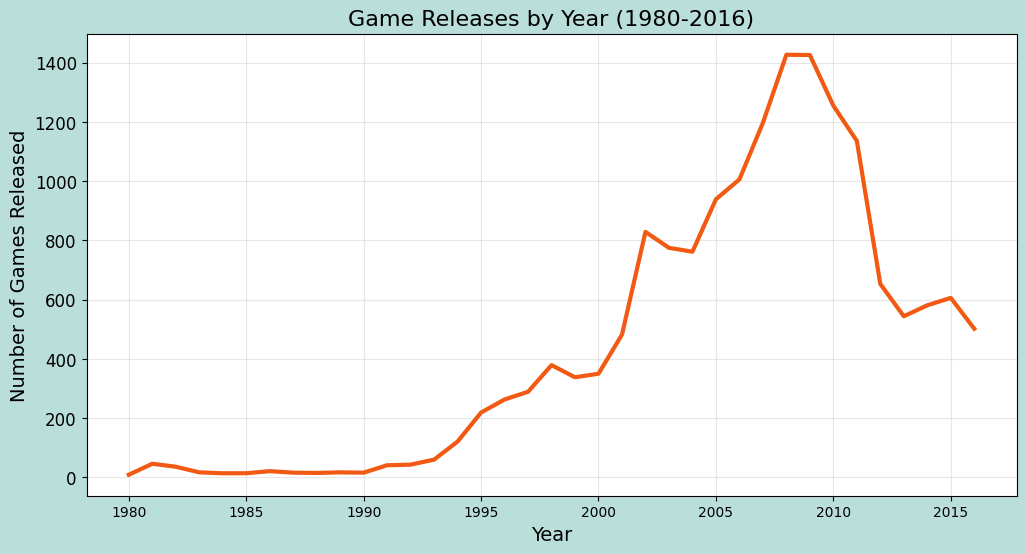

In [15]:
plt.figure(figsize=(12, 6), facecolor='#BADFDB')
plt.plot(yearly_releases.index, yearly_releases['name'], linewidth=3, color='#F25912')
plt.gca().set_facecolor('white')
plt.title('Game Releases by Year (1980-2016)', fontsize = 16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Games Released', fontsize = 14)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
yearly_summary = games.groupby('year_of_release').agg({
    'name': 'count',
    'total_sales': ['mean', 'median', 'std', 'min', 'max'],
    'critic_score': ['mean', 'count'],
    'user_score': ['mean', 'count']
}).round(2)

print(yearly_summary)


                 name total_sales                            critic_score  \
                count        mean median    std   min    max         mean   
year_of_release                                                             
1980                9        1.26   0.77   1.38  0.23   4.31          NaN   
1981               46        0.78   0.46   0.78  0.13   4.50          NaN   
1982               36        0.80   0.54   1.26  0.14   7.81          NaN   
1983               17        0.99   0.77   0.84  0.16   3.20          NaN   
1984               14        3.60   1.48   7.20  0.27  28.31          NaN   
1985               14        3.85   1.02  10.51  0.02  40.24        59.00   
1986               21        1.77   1.36   1.33  0.30   6.50          NaN   
1987               16        1.36   0.88   1.23  0.07   4.38          NaN   
1988               15        3.15   1.51   4.41  0.03  17.28        64.00   
1989               17        4.32   1.61   7.90  0.06  30.26          NaN   

The years that show significant number of games released is during 2005 - 2011. Game releases declined significantly after 2011.

On a side-quest, I found out that these genres have the most yearly releases: Sports (2002-2011 having over 100 to almost 200 yearly releases), Action (2002-2015 having around 125 up to 265 yearly releases), Misc. (which include games like Wii Party, Just Dance, and Minecraft; 2005-2011 having 115 up to 212 yearly releases), and RPG (2006-2010 having over 100 yearly releases). 
Diving further into my analysis for games that had the highest sales, Misc (2005-2010 ranging from about 61M-95M), Action (2007-2013 ranging over 100M), Sports (2006-2010 ranging from 91M to 137M), and Shooter (2007-2015 ranging from 59M to 98M). 
For recent data within the 3 years of 2012-2015, Action (147-265 releases with 72M up to 122M in sales), RPG (71-89 releases with 37M to about 47M in sales), and Sports (53-59 releases with 30M to 45M in sales) have the most games released, and also having the highest sales, including Shooter (only 34-59 releases but having 62M up to 71M in sales). 
In my other observations, it shows that Nintendo dominated the peak period! DS (handheld) and Wii (console) together account for 2,374 games - that's almost half of all releases during those peak years! It showed me that console competition was fierce! With Xbox 360 (706) and PS3 (696) were neck-and-neck in game releases and handheld market was strong with DS (1,371) + PSP (588) = 1,959 handheld games during peak years. I also noticed that fewer games meant higher quality. With peak years doing 1,311 games per year on average and decline years doing 577 games per year (56% drop!) BUT critic scores improved from 67.4 to 72.3!
For market consolidation:Total market sales dropped: 607 million → 289 million per year
Individual game sales stayed similar: 0.46 → 0.49 million average
Median sales dropped slightly: 0.145 → 0.134 million
There was a decline after 2013, where in 2014, efficiency dropped to 0.57. In 2015, efficiency crashed to 0.44 (back to peak-year levels), and in 2016, efficiency collapsed to 0.26 (worst performance!).
What this tells me about The Market Correction Theory is that during 2008-2011, the market was oversaturated with too many games. Between 2012-2013, the industry consolidated and focused on quality for higher efficiency. Between 2014-2016 the market reached a new equilibrium, but total sales declined.

Given that 2016 shows such dramatic changes, I would not feel confident using it to predict 2017. I would focus on the 2012-2015 trends and treat 2016 as an outlier.


## 3.2 Platform Sales Analysis Over Time

In [17]:
yearly_platform_sales = games.groupby(['platform', 'year_of_release'])['total_sales'].sum()
print(yearly_platform_sales)

platform  year_of_release
2600      1980               11.38
          1981               35.68
          1982               28.88
          1983                5.84
          1984                0.27
                             ...  
XB        2008                0.18
XOne      2013               18.96
          2014               54.07
          2015               60.14
          2016               26.15
Name: total_sales, Length: 238, dtype: float64


year_of_release   1980   1981   1982  1983  1984  1985  1986  1987  1988  \
platform                                                                   
2600             11.38  35.68  28.88  5.84  0.27  0.45  0.67  1.94  0.74   
3DO                NaN    NaN    NaN   NaN   NaN   NaN   NaN   NaN   NaN   
3DS                NaN    NaN    NaN   NaN   NaN   NaN   NaN   NaN   NaN   
DC                 NaN    NaN    NaN   NaN   NaN   NaN   NaN   NaN   NaN   
DS                 NaN    NaN    NaN   NaN   NaN  0.02   NaN   NaN   NaN   

year_of_release  1989  ...    2007    2008    2009   2010   2011   2012  \
platform               ...                                                
2600             0.63  ...     NaN     NaN     NaN    NaN    NaN    NaN   
3DO               NaN  ...     NaN     NaN     NaN    NaN    NaN    NaN   
3DS               NaN  ...     NaN     NaN     NaN    NaN  63.20  51.36   
DC                NaN  ...    0.02    0.04     NaN    NaN    NaN    NaN   
DS               

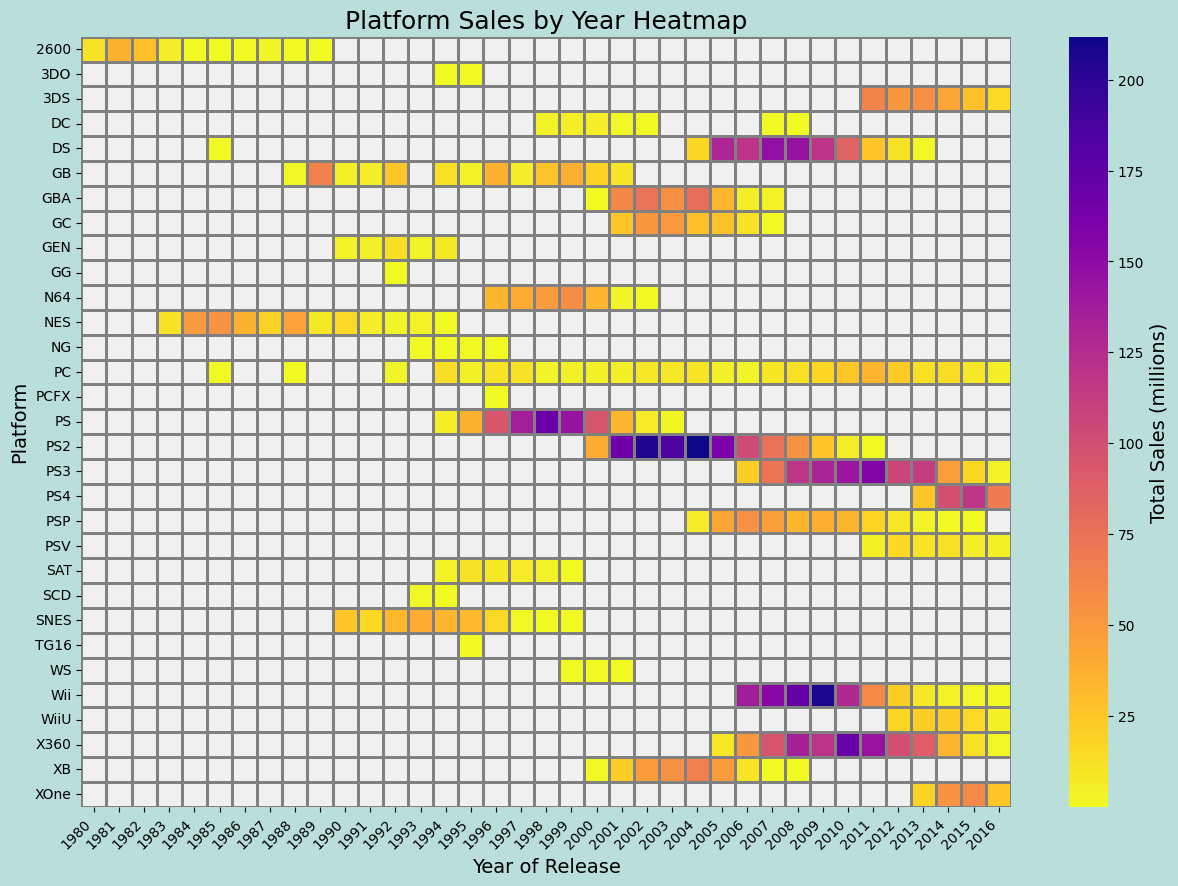

In [18]:
platform_sales_pivot = yearly_platform_sales.unstack(level='year_of_release')
print(platform_sales_pivot.head())
plt.figure(figsize=(15, 10), facecolor='#BADFDB')
ax = sns.heatmap(platform_sales_pivot,
                 cmap='plasma_r',
                 annot=False,
                 fmt='.1f',
                 cbar_kws={'label': 'Total Sales (millions)'},
                 linewidths=1.0,
                 linecolor='gray')
plt.title('Platform Sales by Year Heatmap', fontsize=18)
plt.xlabel('Year of Release', fontsize=14)
plt.ylabel('Platform', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.gca().set_facecolor('#f0f0f0')
cbar = ax.collections[0].colorbar
cbar.set_label('Total Sales (millions)', fontsize=14)
plt.show()


In [19]:
print('Recent Game Data')
recent_data = games[games['year_of_release'].isin([2012, 2013, 2014, 2015])]
print(recent_data)


platform_yearly_sales = recent_data.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()
print()
print('Platform Yearly Sales')
print(platform_yearly_sales)
platform_pivot = platform_yearly_sales.pivot(index='platform', columns='year_of_release', values='total_sales')
print()
print("Platform sales by year:")
print(platform_pivot)

yoy_changes = platform_pivot.pct_change(axis=1) * 100
print()
print("\nYear-over-year percentage changes:")
print(yoy_changes.round(2))

print()
print('Platform Slope')
def calculate_slope(platform_data):
  
    years = [2012, 2013, 2014, 2015]
    slopes = {}
    
    for platform in platform_data['platform'].unique():
        platform_sales = platform_data[platform_data['platform'] == platform]
        
    
        if len(platform_sales) >= 3:
            x = platform_sales['year_of_release'].values
            y = platform_sales['total_sales'].values
            
          
            slope, intercept, r_value, p_value, std_err = st.linregress(x, y)
            slopes[platform] = {
                'slope': slope,
                'r_squared': r_value**2,
                'p_value': p_value
            }
    
    return slopes

platform_slopes = calculate_slope(platform_yearly_sales)
print()
print("Platform trends (slope per year):")
for platform, stats_dict in platform_slopes.items():
    print(f"{platform}: {stats_dict['slope']:.2f} million/year (R²={stats_dict['r_squared']:.3f})")

print()
print('Platform Timeline')
platform_timeline = []
for platform in platform_sales_pivot.index:
    platform_data = platform_sales_pivot.loc[platform]
    non_zero_data = platform_data[platform_data > 0]
    
    if len(non_zero_data) > 0:
        first_year = non_zero_data.index.min()
        last_year = non_zero_data.index.max()
        peak_year = non_zero_data.idxmax()
        peak_sales = non_zero_data.max()
        
        platform_timeline.append({
            'Platform': platform,
            'First_Active': first_year,
            'Last_Active': last_year,
            'Peak_Year': peak_year,
            'Peak_Sales': peak_sales,
            'Years_Active': last_year - first_year + 1
        })

timeline_df = pd.DataFrame(platform_timeline)
timeline_df = timeline_df.sort_values('Last_Active')
print("Complete Platform Timeline:")
print(timeline_df)


Recent Game Data
                                             name platform  year_of_release  \
16                             Grand Theft Auto V      PS3             2013   
23                             Grand Theft Auto V     X360             2013   
31                      Call of Duty: Black Ops 3      PS4             2015   
33                            Pokemon X/Pokemon Y      3DS             2013   
34                     Call of Duty: Black Ops II      PS3             2012   
...                                           ...      ...              ...   
16674               Tsukigime Ranko's Longest Day      PS3             2014   
16678                              End of Nations       PC             2012   
16682  Grisaia no Kajitsu: La Fruit de la Grisaia      PSP             2013   
16692           Metal Gear Solid V: Ground Zeroes       PC             2014   
16707                            Aiyoku no Eustia      PSV             2014   

              genre  na_sales  eu_

C:\Users\britn\AppData\Local\Temp\ipykernel_9740\1455442266.py:15: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  yoy_changes = platform_pivot.pct_change(axis=1) * 100


The platforms that show consisitent sales over recent years include PS4 and XOne. They are also the most recent platforms that have came out, meaning newer games and technology with significant imporvements in graphics, processing power, and online features, compared to earlier platforms. These 2 platforms have digital downloads, streaming services, and more online multiplayer options. Also, modern consoles are designed to last longer with regular updates rather than frequent replacements. In my research, I noticed that Action, Shooter, and Sports games were the top 3 genres for both platforms!

A platform that has disappeared in recent years is the Nintendo DS,  but before the year 2012, multiple other platforms have also disappeared, including: 2600, GG, SCD, GEN, NES, 3DO, TG16, NG, PCFX, SNES, SAT, WS, GB, N64, PS, GC, GBA, XB, DC, and (my personal favorite) PS2.

Out of those 21 discontinued platforms, 38% only lasted 5 years or less, 33% lasted 6-10 years, and only about 24% made it over 10 years. 4 platforms were handhelds lasting quite a long time, ranging from GG (the least amount of time) only 1 year, GBA lasting 8 years, GB lasting 14 years, and the DS (also my personal favorite) going strong for 29 years!


Based off of these insights, campaigning Action, Sports, and/or Shooter games for both XOne and PS4 would be the most popular recommendation. BUT, looking at favorite genre by region, NA, EU, and Other regions, show that Shooter games are the most popular, with Action games not too far behind! With JP's favorite genre being Action, but not really having high sales anyways with 5.95 in sales, it's still helping with the statistics!

## 3.3 Determining Relevant Time Period

In [20]:
relevant_years = [2013, 2014, 2015]
games_relevant = games[games['year_of_release'].isin(relevant_years)]

print(games_relevant)
print()
print(f"Total games in 2013-2015: {len(games_relevant)}")
games_by_year = games_relevant['year_of_release'].value_counts().sort_index()
print()
print("Games produced by year:")
print()
print(games_by_year)
yearly_breakdown = games_relevant.groupby('year_of_release').agg({
    'name': 'count',
    'total_sales': ['sum', 'mean']
}).round(2)
print()
print("Detailed yearly breakdown:")
print(yearly_breakdown)

                                                    name platform  \
16                                    Grand Theft Auto V      PS3   
23                                    Grand Theft Auto V     X360   
31                             Call of Duty: Black Ops 3      PS4   
33                                   Pokemon X/Pokemon Y      3DS   
42                                    Grand Theft Auto V      PS4   
...                                                  ...      ...   
16668  Fujiko F. Fujio Characters: Great Assembly! Sl...      3DS   
16674                      Tsukigime Ranko's Longest Day      PS3   
16682         Grisaia no Kajitsu: La Fruit de la Grisaia      PSP   
16692                  Metal Gear Solid V: Ground Zeroes       PC   
16707                                   Aiyoku no Eustia      PSV   

       year_of_release         genre  na_sales  eu_sales  jp_sales  \
16                2013        Action      7.02      9.09      0.98   
23                2013        A

The years I selected was 2013-2015 because they are the most recent. It shows current sales and patterns, and these years capture the current-gen consoles (PS4, Xbox One) in their growth phase. For 1980-2012 there was 51.68% of games with reviews and for 2013-2015 there was 54% of games with reviews. Since one of the first online reviewing systems (Metacritic) launched in 2001, it shows why about 2 decades worth of games were under-reviwed, due to lack of that platform, compared to 3 years worth, where online reviewing systems were more planted and structred and easily accessible. Also, it has become more apparent that reviews ARE important, and should be analyzed for the public.
This period reflects the current market condition better than the previous years, simply because its closer to this time period and more integrated with how the economy is running. 
The factors that influenced my decision are that the top 2 platforms are still in working condition and GROWING! 

## 3.4 Platform Performance Analysis

In [21]:
platform_counts = games_relevant['platform'].value_counts()
print("Platform game counts (2013-2015):")
print(platform_counts)

def get_top_platforms_by_year(df, year, top_n=3):
    year_data = df[df['year_of_release'] == year]
    return year_data['platform'].value_counts().head(top_n)

for year in [2013, 2014, 2015]:
    print(f"\nTop platforms in {year}:")
    print(get_top_platforms_by_year(games_relevant, year))
    


Platform game counts (2013-2015):
platform
PS3     307
PSV     273
3DS     257
PS4     228
X360    173
XOne    160
PC      135
WiiU    101
PSP      67
Wii      22
DS        8
Name: count, dtype: int64

Top platforms in 2013:
platform
PS3     126
3DS      91
X360     75
Name: count, dtype: int64

Top platforms in 2014:
platform
PS3    108
PSV    100
3DS     80
Name: count, dtype: int64

Top platforms in 2015:
platform
PS4    137
PSV    110
3DS     86
Name: count, dtype: int64


In [22]:
yearly_trends = games_relevant.groupby('year_of_release').agg({
    'total_sales': ['sum', 'mean', 'count']
}).round(2)

print("\nYearly sales trends:")
print(yearly_trends)

platform_sales_by_year = games_relevant.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack(fill_value=0)

print("Platform sales by year (2013-2015):")
print(platform_sales_by_year)


Yearly sales trends:
                total_sales            
                        sum  mean count
year_of_release                        
2013                 361.24  0.66   544
2014                 331.53  0.57   581
2015                 267.98  0.44   606
Platform sales by year (2013-2015):
platform           3DS    DS     PC     PS3     PS4   PSP    PSV   Wii   WiiU  \
year_of_release                                                                 
2013             56.57  1.54  12.38  113.25   25.99  3.14  10.59  8.59  21.65   
2014             43.76  0.00  13.28   47.76  100.00  0.24  11.90  3.75  22.03   
2015             27.78  0.00   8.52   16.82  118.90  0.12   6.25  1.14  16.35   

platform          X360   XOne  
year_of_release                
2013             88.58  18.96  
2014             34.74  54.07  
2015             11.96  60.14  


platform            PS4   XOne
year_of_release               
2013              25.99  18.96
2014             100.00  54.07
2015             118.90  60.14


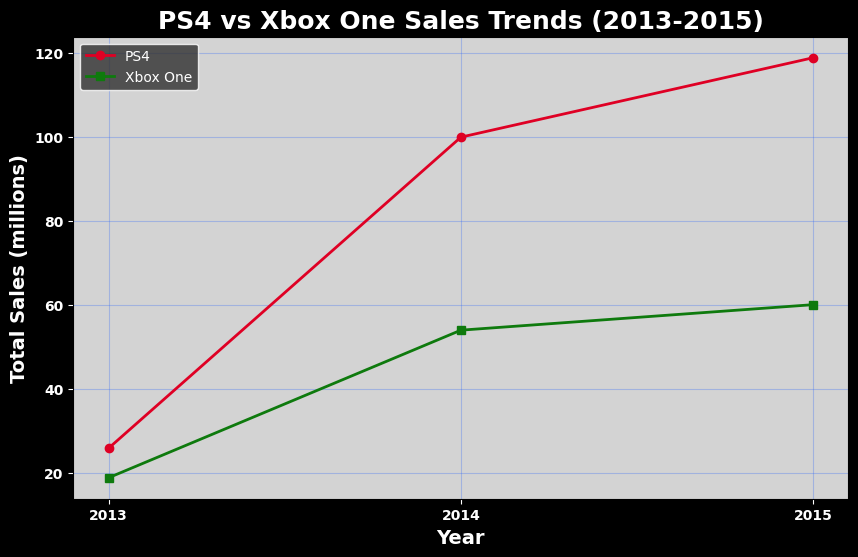

In [23]:
ps4_xone_data = platform_sales_by_year[['PS4', 'XOne']]
print(ps4_xone_data)

plt.figure(figsize=(10, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('#d3d3d3')
plt.plot(ps4_xone_data.index, ps4_xone_data['PS4'],
         marker='o', linewidth=2, label='PS4', color='#df0024')
plt.plot(ps4_xone_data.index, ps4_xone_data['XOne'],
         marker='s', linewidth=2, label='Xbox One', color='#0e7a0d')
plt.title('PS4 vs Xbox One Sales Trends (2013-2015)',
          fontsize=18, color='white', weight='bold')
plt.xlabel('Year', fontsize=14, color='white', weight='bold')
plt.ylabel('Total Sales (millions)', fontsize=14, color='white', weight='bold')
plt.tick_params(colors='white')
plt.xticks(fontweight='bold') 
plt.xticks([2013, 2014, 2015])
plt.yticks(fontweight='bold')
plt.legend(facecolor='#2F2F2F', edgecolor='white', labelcolor='white')
plt.grid(True, alpha=0.3, color='#2E67F8')
plt.show()

## 3.5 Sales Distribution Analysis

                              name platform  year_of_release    genre  \
31       Call of Duty: Black Ops 3      PS4             2015  Shooter   
42              Grand Theft Auto V      PS4             2014   Action   
77                         FIFA 16      PS4             2015   Sports   
87    Star Wars Battlefront (2015)      PS4             2015  Shooter   
92  Call of Duty: Advanced Warfare      PS4             2014  Shooter   

    na_sales  eu_sales  jp_sales  other_sales  critic_score  user_score  \
31      6.03      5.86      0.36         2.38           NaN         NaN   
42      3.96      6.31      0.38         1.97          97.0         8.3   
77      1.12      6.12      0.06         1.28          82.0         4.3   
87      2.99      3.49      0.22         1.28           NaN         NaN   
92      2.81      3.48      0.14         1.23          83.0         5.7   

   rating  total_sales  missing_count  critic_score_missing  has_critic_score  \
31    NaN        14.63       

C:\Users\britn\AppData\Local\Temp\ipykernel_9740\94686797.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(box_data, labels=['PS4', 'Xbox One'], patch_artist=True)


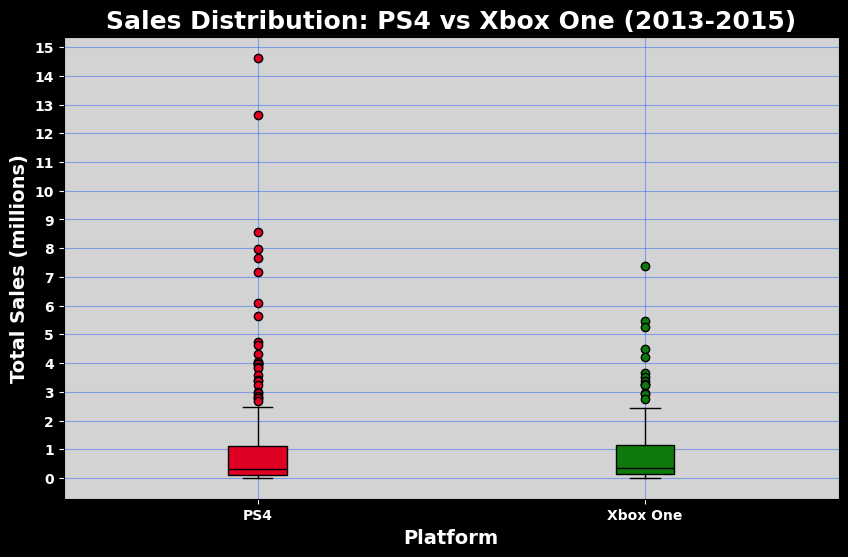

In [24]:
ps4_xone_games = games_relevant[games_relevant['platform'].isin(['PS4', 'XOne'])]
print(ps4_xone_games.head())

plt.figure(figsize=(10, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('#d3d3d3')

box_data = [ps4_xone_games[ps4_xone_games['platform'] == 'PS4']['total_sales'],
           ps4_xone_games[ps4_xone_games['platform'] == 'XOne']['total_sales']]

bp = plt.boxplot(box_data, labels=['PS4', 'Xbox One'], patch_artist=True)
bp['boxes'][0].set_facecolor('#df0024')
bp['boxes'][1].set_facecolor('#0e7a0d')
bp['boxes'][0].set_edgecolor('black')
bp['boxes'][1].set_edgecolor('black')
bp['boxes'][0].set_linewidth(1)
bp['boxes'][1].set_linewidth(1)

for i in range(2):
    color = '#df0024' if i == 0 else '#0e7a0d'
    bp['whiskers'][i*2].set_color('black')
    bp['whiskers'][i*2+1].set_color('black')
    bp['whiskers'][i*2].set_linewidth(1)
    bp['whiskers'][i*2+1].set_linewidth(1)
    bp['caps'][i*2].set_color('black')
    bp['caps'][i*2+1].set_color('black')
    bp['caps'][i*2].set_linewidth(1)
    bp['caps'][i*2+1].set_linewidth(1)
    bp['medians'][i].set_color('black')
    bp['medians'][i].set_linewidth(1)
    bp['fliers'][i].set_markerfacecolor(color)
    bp['fliers'][i].set_markeredgecolor('black')
    bp['fliers'][i].set_markersize(6)
    bp['fliers'][i].set_linewidth(1) 

plt.title('Sales Distribution: PS4 vs Xbox One (2013-2015)',
          fontsize=18, color='white', weight='bold')
plt.xlabel('Platform', fontsize=14, color='white', weight='bold')
plt.ylabel('Total Sales (millions)', fontsize=14, color='white', weight='bold')
plt.tick_params(colors='white')
plt.xticks(fontweight='bold')
plt.yticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], fontweight='bold')
plt.grid(True, alpha=0.5, color='#2E67F8', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.show()

In [25]:
ps4_stats = ps4_xone_games[ps4_xone_games['platform'] == 'PS4']['total_sales'].describe()
xone_stats = ps4_xone_games[ps4_xone_games['platform'] == 'XOne']['total_sales'].describe()

print("PS4 Sales Statistics:")
print(ps4_stats)
print("\nXbox One Sales Statistics:")
print(xone_stats)
print("\nAdditional Platform Comparisons:")
print(f"PS4 - Total Games: {len(ps4_xone_games[ps4_xone_games['platform'] == 'PS4'])}")
print(f"Xbox One - Total Games: {len(ps4_xone_games[ps4_xone_games['platform'] == 'XOne'])}")

total_sales_both = ps4_xone_games['total_sales'].sum()
ps4_market_share = ps4_xone_games[ps4_xone_games['platform'] == 'PS4']['total_sales'].sum() / total_sales_both * 100
xone_market_share = ps4_xone_games[ps4_xone_games['platform'] == 'XOne']['total_sales'].sum() / total_sales_both * 100

print(f"\nMarket Share (2013-2015):")
print(f"PS4: {ps4_market_share:.1f}%")
print(f"Xbox One: {xone_market_share:.1f}%")

PS4 Sales Statistics:
count    228.000000
mean       1.074079
std        1.899788
min        0.010000
25%        0.097500
50%        0.310000
75%        1.105000
max       14.630000
Name: total_sales, dtype: float64

Xbox One Sales Statistics:
count    160.000000
mean       0.832313
std        1.182243
min        0.010000
25%        0.130000
50%        0.350000
75%        1.137500
max        7.390000
Name: total_sales, dtype: float64

Additional Platform Comparisons:
PS4 - Total Games: 228
Xbox One - Total Games: 160

Market Share (2013-2015):
PS4: 64.8%
Xbox One: 35.2%


## 3.6 Review Score Impact Analysis

# Choose a popular platform based on your previous analysis
Based on my previous analysis, I will be focusing on PS4.

PS4 games found: 228
Games with critic scores: 154
Games with user scores: 156


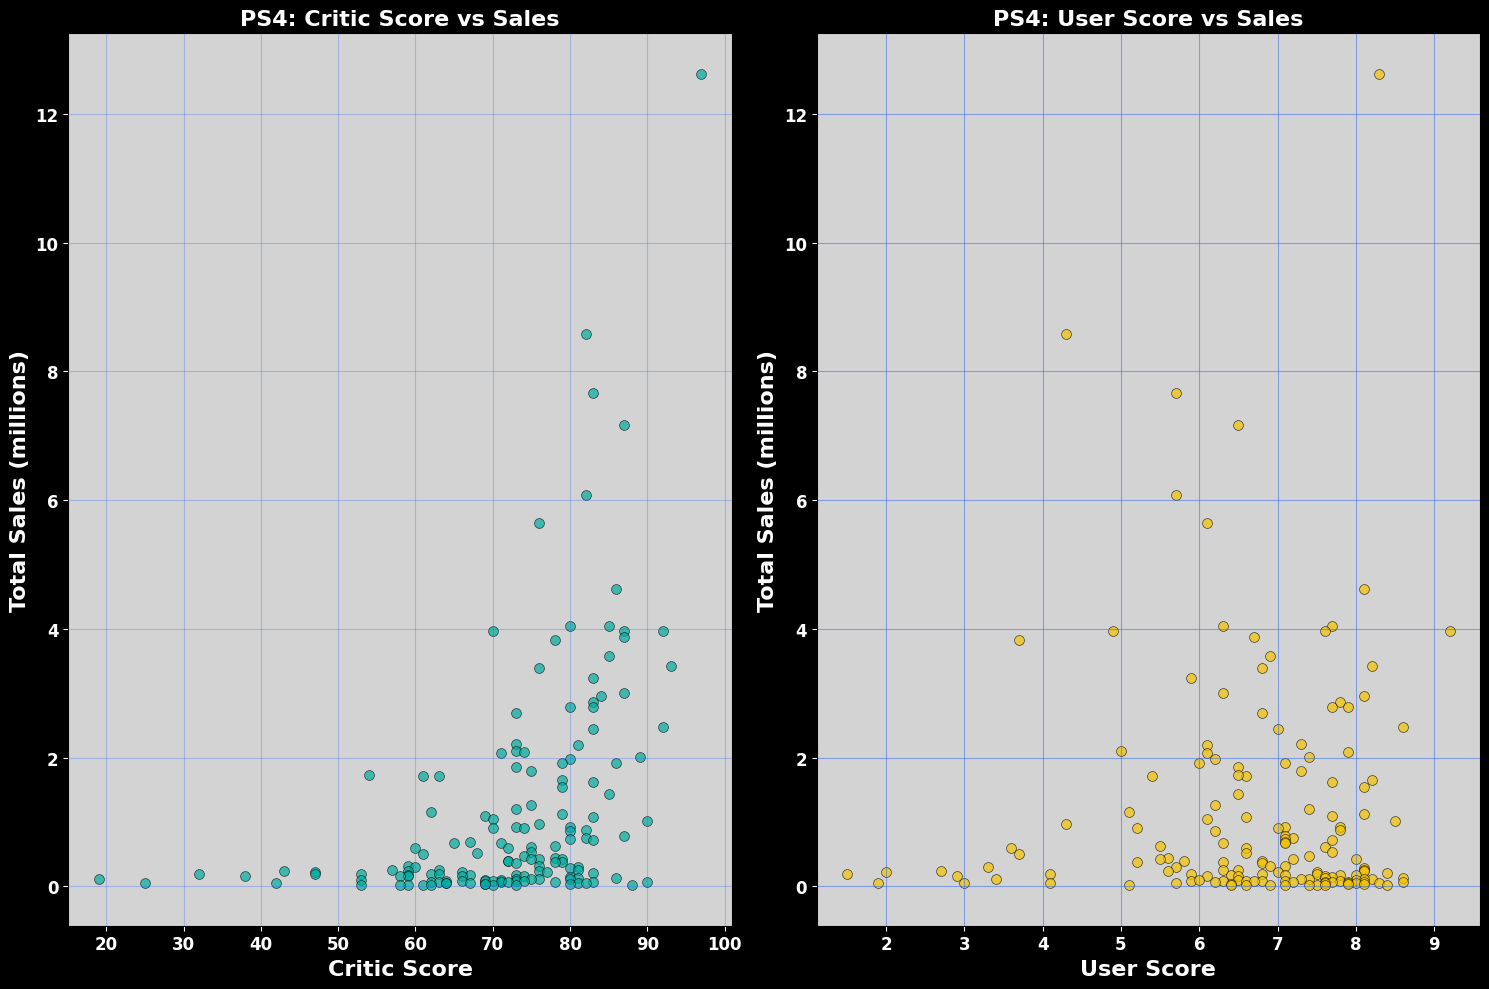

In [26]:
ps4_games = games_relevant[games_relevant['platform'] == 'PS4']
print(f"PS4 games found: {len(ps4_games)}")
print(f"Games with critic scores: {ps4_games['critic_score'].notna().sum()}")
print(f"Games with user scores: {ps4_games['user_score'].notna().sum()}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10), facecolor='black')

ps4_with_critic = ps4_games.dropna(subset=['critic_score'])
ps4_with_user = ps4_games.dropna(subset=['user_score'])

ax1.scatter(ps4_with_critic['critic_score'], ps4_with_critic['total_sales'], 
           alpha=0.7, color='#00AC9F', s=50, edgecolors='black', linewidth=0.5)
ax1.set_facecolor('#d3d3d3')
ax1.set_title('PS4: Critic Score vs Sales', fontsize=16, color='white', weight='bold')
ax1.set_xlabel('Critic Score', fontsize=16, color='white', weight='bold')
ax1.set_ylabel('Total Sales (millions)', fontsize=16, color='white', weight='bold')
ax1.tick_params(colors='white', labelsize=12)  # axis numbers: size 12, bold added below
ax1.grid(True, alpha=0.3, color='#2E67F8')

for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_weight('bold')

ax2.scatter(ps4_with_user['user_score'], ps4_with_user['total_sales'],
           alpha=0.7, color='#f3c300', s=50, edgecolors='black', linewidth=0.5)
ax2.set_facecolor('#d3d3d3')
ax2.set_title('PS4: User Score vs Sales', fontsize=16, color='white', weight='bold')
ax2.set_xlabel('User Score', fontsize=16, color='white', weight='bold')
ax2.set_ylabel('Total Sales (millions)', fontsize=16, color='white', weight='bold')
ax2.tick_params(colors='white', labelsize=12)  # axis numbers: size 12, bold added below
ax2.grid(True, alpha=0.5, color='#2E67F8')

for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_weight('bold')

plt.tight_layout()
plt.show()


In [27]:
critic_correlation = ps4_with_critic['critic_score'].corr(ps4_with_critic['total_sales'])
print(f"PS4 Critic Score vs Sales Correlation: {critic_correlation:.3f}")

user_correlation = ps4_with_user['user_score'].corr(ps4_with_user['total_sales'])
print(f"PS4 User Score vs Sales Correlation: {user_correlation:.3f}")
print(f"\nCorrelation Analysis Summary:")
print(f"- Critic Score correlation: {critic_correlation:.3f}")
print(f"- User Score correlation: {user_correlation:.3f}")
print(f"\nData Coverage:")
print(f"- Games with critic scores: {len(ps4_with_critic)} out of {len(ps4_games)} ({len(ps4_with_critic)/len(ps4_games)*100:.1f}%)")
print(f"- Games with user scores: {len(ps4_with_user)} out of {len(ps4_games)} ({len(ps4_with_user)/len(ps4_games)*100:.1f}%)")


PS4 Critic Score vs Sales Correlation: 0.432
PS4 User Score vs Sales Correlation: 0.024

Correlation Analysis Summary:
- Critic Score correlation: 0.432
- User Score correlation: 0.024

Data Coverage:
- Games with critic scores: 154 out of 228 (67.5%)
- Games with user scores: 156 out of 228 (68.4%)


### Findings: PS4 Review Scores vs Sales

- **Critic Score correlation (0.432)** shows a moderate positive relationship with sales.  
  This means PS4 games with higher critic reviews tend to sell more, and critic reception is a meaningful predictor of commercial success.

- **User Score correlation (0.024)** is extremely weak.  
  This suggests that user ratings have almost no measurable relationship with sales for PS4 games.

- **Interpretation:**  
  Critic reviews appear to influence consumer behavior more strongly than user reviews, possibly because critic scores are published at launch and used in marketing, while user scores accumulate later and vary widely in reliability.

- **Data coverage:**  
  With ~67% of PS4 games having critic/user scores, the sample is large enough to trust these patterns.


## 3.7 Cross-Platform Comparison

In [28]:
game_counts = games_relevant.groupby('name').agg({
    'platform': ['count', 'nunique'],
    'total_sales': 'sum'
}).round(2)

game_counts.columns = ['total_releases', 'platform_count', 'combined_sales']

multi_platform_games = game_counts[game_counts['platform_count'] >= 2]
multi_platform_games = multi_platform_games.sort_values('platform_count', ascending=False)

print("Games released on multiple platforms:")
print(f"Total multi-platform games: {len(multi_platform_games)}")
print("\nTop 10 games by number of platforms:")
print(multi_platform_games.head(10))

Games released on multiple platforms:
Total multi-platform games: 346

Top 10 games by number of platforms:
                                 total_releases  platform_count  \
name                                                              
FIFA 14                                       9               9   
LEGO Marvel Super Heroes                      9               9   
FIFA 15                                       8               8   
The LEGO Movie Videogame                      8               8   
Angry Birds Star Wars                         8               8   
LEGO The Hobbit                               8               8   
LEGO Jurassic World                           8               8   
Lego Batman 3: Beyond Gotham                  8               8   
Skylanders SWAP Force                         7               7   
The Amazing Spider-Man 2 (2014)               7               7   

                                 combined_sales  
name                                 

Cross-platform analysis:
Total records found: 42

=== FIFA 14 ===
PS3: 6.46M
X360: 4.22M
PS4: 3.01M
XOne: 1.16M
PSV: 0.41M
PC: 0.40M
Wii: 0.38M
3DS: 0.23M
PSP: 0.19M
Game Total Sales: 16.46M
Available on 9 platforms

=== LEGO Marvel Super Heroes ===
X360: 2.22M
PS3: 1.83M
PS4: 1.62M
XOne: 1.05M
3DS: 0.89M
WiiU: 0.74M
PSV: 0.51M
DS: 0.38M
PC: 0.17M
Game Total Sales: 9.41M
Available on 9 platforms

=== LEGO The Hobbit ===
PS4: 0.60M
PS3: 0.46M
X360: 0.45M
XOne: 0.27M
3DS: 0.24M
WiiU: 0.22M
PSV: 0.14M
PC: 0.05M
Game Total Sales: 2.43M
Available on 8 platforms

=== LEGO Jurassic World ===
PS4: 0.90M
X360: 0.87M
PS3: 0.85M
XOne: 0.66M
3DS: 0.62M
WiiU: 0.52M
PSV: 0.23M
PC: 0.04M
Game Total Sales: 4.69M
Available on 8 platforms

=== FIFA 15 ===
PS4: 6.08M
PS3: 4.28M
X360: 2.92M
XOne: 2.18M
PSV: 0.60M
Wii: 0.56M
3DS: 0.46M
PC: 0.29M
Game Total Sales: 17.37M
Available on 8 platforms


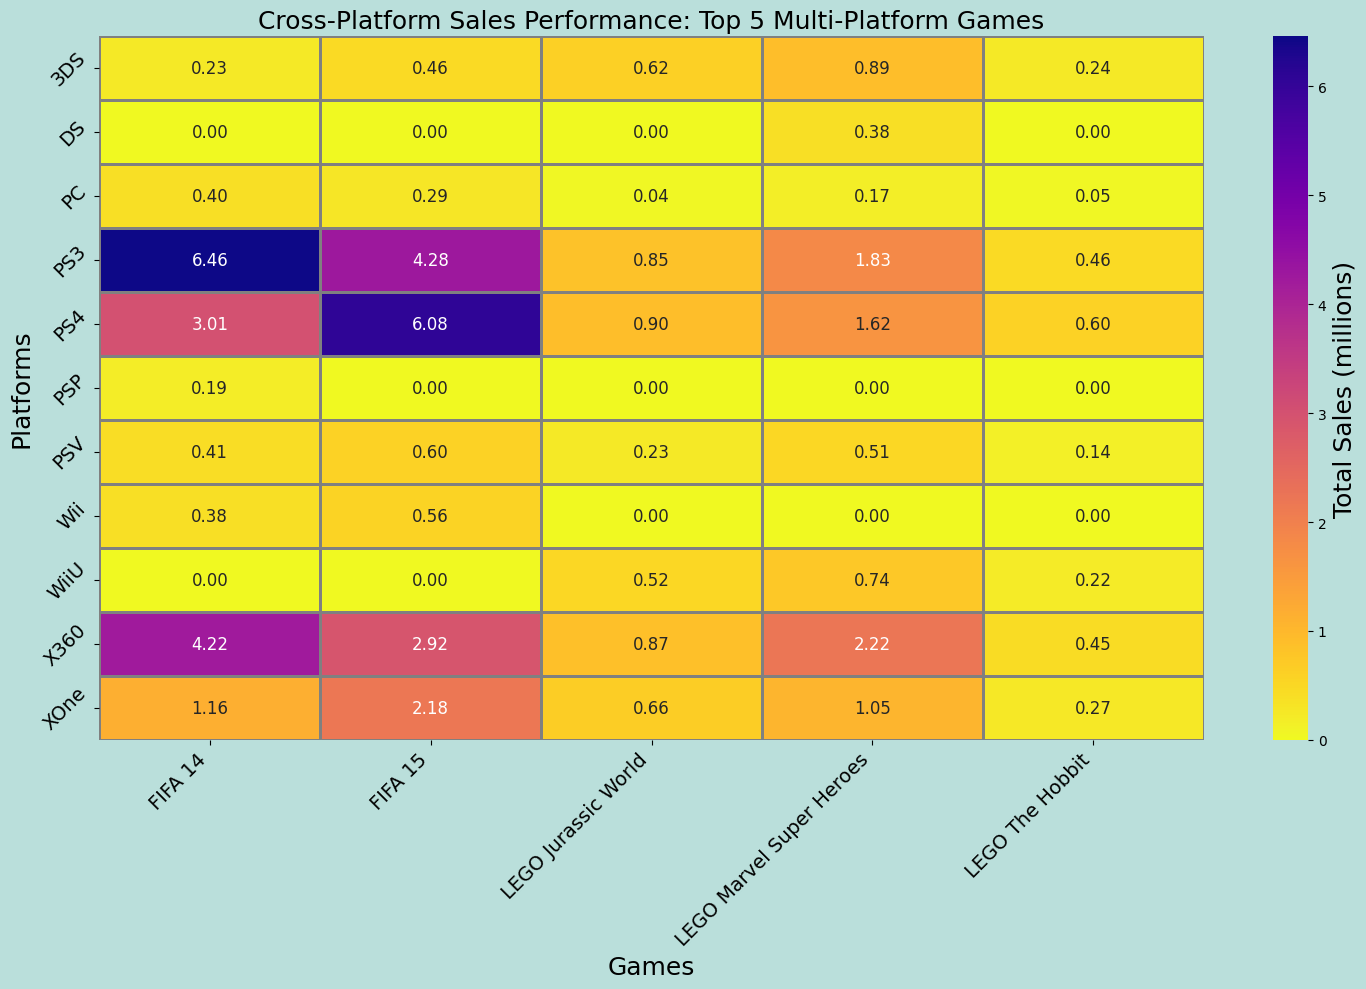

In [29]:
top_5_games = ['FIFA 14', 'LEGO Marvel Super Heroes', 'LEGO The Hobbit', 'LEGO Jurassic World', 'FIFA 15']

cross_platform_data = games_relevant[games_relevant['name'].isin(top_5_games)]

print("Cross-platform analysis:")
print(f"Total records found: {len(cross_platform_data)}")

for game in top_5_games:
    game_data = cross_platform_data[cross_platform_data['name'] == game]
    print(f"\n=== {game} ===")
    
    for _, row in game_data.iterrows():
        print(f"{row['platform']}: {row['total_sales']:.2f}M")
    
    print(f"Game Total Sales: {game_data['total_sales'].sum():.2f}M")
    print(f"Available on {len(game_data)} platforms")

platform_game_sales = cross_platform_data.pivot_table(
    values='total_sales', 
    index='platform', 
    columns='name', 
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(15, 10), facecolor='#BADFDB')
ax = sns.heatmap(platform_game_sales, 
                 cmap='plasma_r',
                 annot=True,
                 annot_kws={'size': 12},
                 fmt='.2f', 
                 cbar_kws={'label': 'Total Sales (millions)'},
                 linewidths=1.0,
                 linecolor='gray')
plt.title('Cross-Platform Sales Performance: Top 5 Multi-Platform Games', fontsize=18)
plt.xlabel('Games', fontsize=18)
plt.ylabel('Platforms', fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(fontsize=14, rotation=45)
plt.gca().set_facecolor('#f0f0f0')
cbar = ax.collections[0].colorbar
cbar.set_label('Total Sales (millions)', fontsize=18)
plt.tight_layout()
plt.show()

## 3.8 Genre Analysis

In [30]:
genre_performance = games_relevant.groupby('genre').agg({
    'name': 'count',
    'total_sales': ['sum', 'mean', 'median', 'std']
}).round(2)

genre_performance.columns = ['game_count', 'total_sales', 'avg_sales', 'median_sales', 'std_sales']
print("Genre Performance Analysis (2013-2015):")
print(genre_performance.sort_values('total_sales', ascending=False))

Genre Performance Analysis (2013-2015):
              game_count  total_sales  avg_sales  median_sales  std_sales
genre                                                                    
Action               588       291.76       0.50          0.13       1.41
Shooter              140       194.76       1.39          0.58       2.19
Role-Playing         238       127.71       0.54          0.13       1.42
Sports               166       127.16       0.77          0.36       1.23
Misc                 123        60.22       0.49          0.17       1.12
Platform              59        39.40       0.67          0.31       0.86
Racing                61        37.10       0.61          0.22       1.10
Fighting              64        30.84       0.48          0.13       1.16
Simulation            44        19.87       0.45          0.14       0.99
Adventure            189        19.82       0.10          0.03       0.23
Strategy              43         8.95       0.21          0.08       0.3

In [31]:
genre_performance_sorted = genre_performance.sort_values('total_sales', ascending=False)
print("Genres sorted by total sales (2013-2015):")
print(genre_performance_sorted)

Genres sorted by total sales (2013-2015):
              game_count  total_sales  avg_sales  median_sales  std_sales
genre                                                                    
Action               588       291.76       0.50          0.13       1.41
Shooter              140       194.76       1.39          0.58       2.19
Role-Playing         238       127.71       0.54          0.13       1.42
Sports               166       127.16       0.77          0.36       1.23
Misc                 123        60.22       0.49          0.17       1.12
Platform              59        39.40       0.67          0.31       0.86
Racing                61        37.10       0.61          0.22       1.10
Fighting              64        30.84       0.48          0.13       1.16
Simulation            44        19.87       0.45          0.14       0.99
Adventure            189        19.82       0.10          0.03       0.23
Strategy              43         8.95       0.21          0.08       0

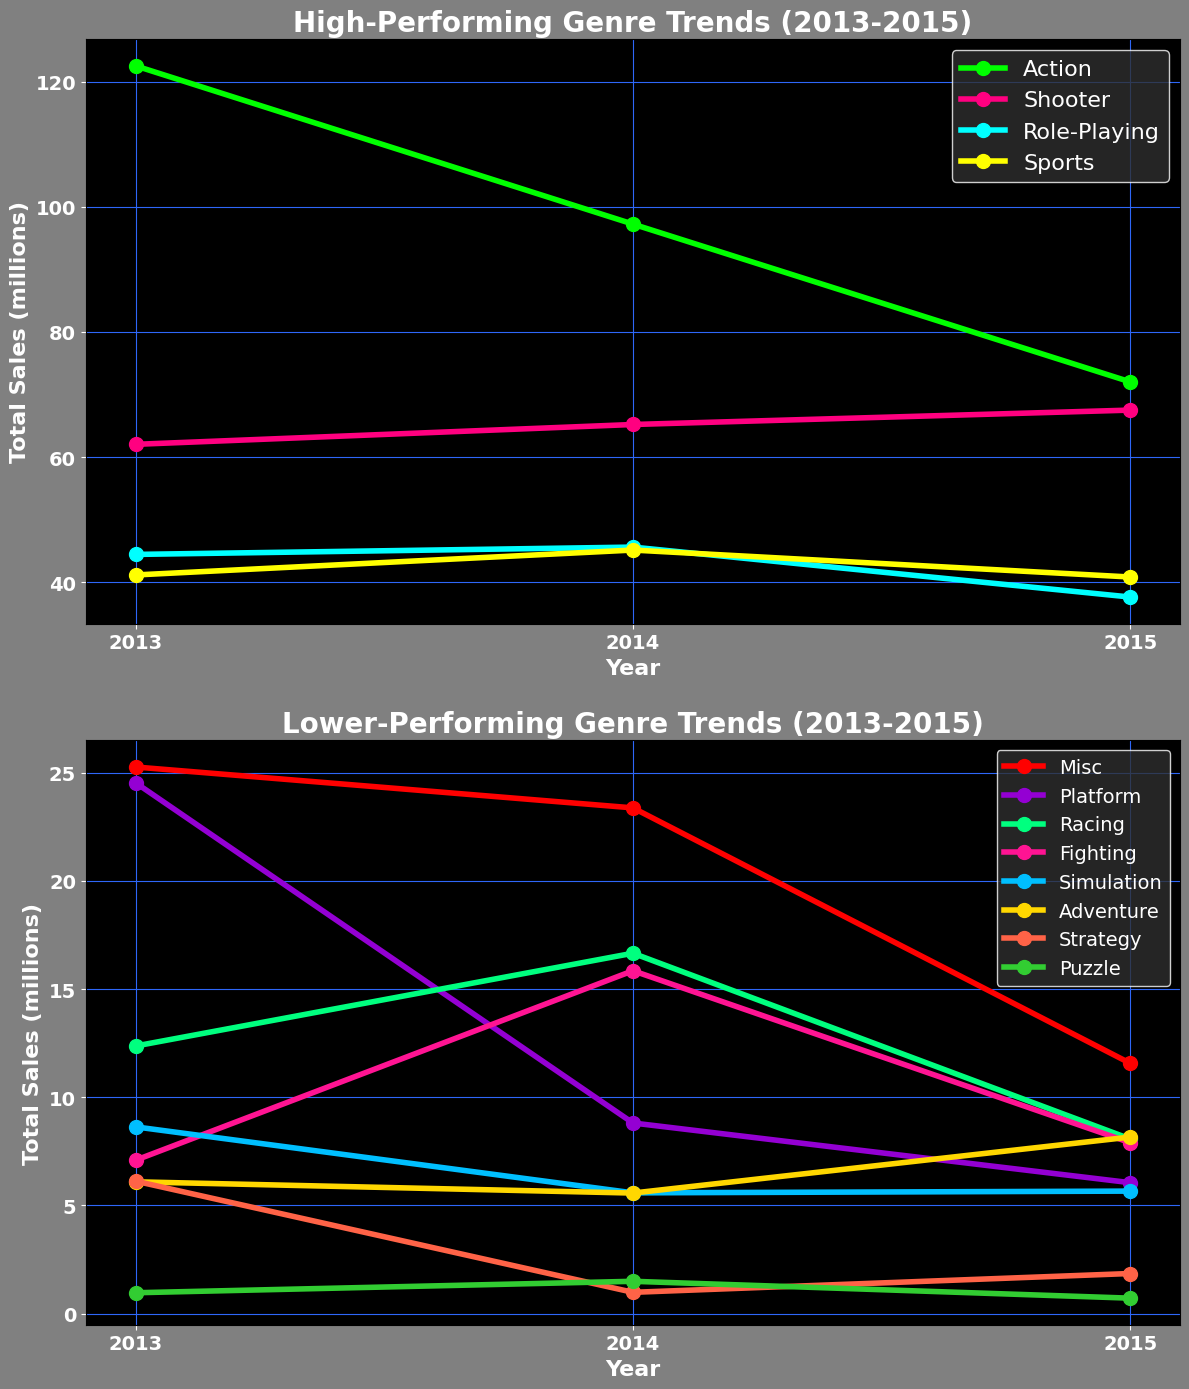

In [32]:
genre_yearly_sales = games_relevant.groupby(['year_of_release', 'genre'])['total_sales'].sum().unstack(fill_value=0)

high_performers = ['Action', 'Shooter', 'Role-Playing', 'Sports']
low_performers = ['Misc', 'Platform', 'Racing', 'Fighting', 'Simulation', 'Adventure', 'Strategy', 'Puzzle']

high_colors = ['#00FF00', '#FF0080', '#00FFFF', '#FFFF00']
low_colors = ['red', '#9400D3', '#00FF7F', '#FF1493', '#00BFFF', '#FFD700', '#FF6347', '#32CD32']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14), facecolor='gray')



for i, genre in enumerate(high_performers):
    if genre in genre_yearly_sales.columns:
        ax1.plot(genre_yearly_sales.index, genre_yearly_sales[genre], 
                marker='o', linewidth=4, label=genre, markersize=10,
                color=high_colors[i])

ax1.set_facecolor('black')
ax1.set_title('High-Performing Genre Trends (2013-2015)', color='white', fontsize=20, fontweight='bold')
ax1.set_xlabel('Year', color='white', fontsize=16, fontweight='bold')
ax1.set_ylabel('Total Sales (millions)', color='white', fontsize=16, fontweight='bold')
ax1.legend(facecolor='#2F2F2F', edgecolor='white', labelcolor='white', fontsize=16)
ax1.tick_params(colors='white', labelsize=14)
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_weight('bold')
ax1.grid(True, alpha=1, color='#2E67F8')
ax1.set_xticks([2013, 2014, 2015])

for i, genre in enumerate(low_performers):
    if genre in genre_yearly_sales.columns:
        ax2.plot(genre_yearly_sales.index, genre_yearly_sales[genre], 
                marker='o', linewidth=4, label=genre, markersize=10,
                color=low_colors[i])

ax2.set_facecolor('black')
ax2.set_title('Lower-Performing Genre Trends (2013-2015)', color='white', fontsize=20, fontweight='bold')
ax2.set_xlabel('Year', color='white', fontsize=16, fontweight='bold')
ax2.set_ylabel('Total Sales (millions)', color='white', fontsize=16, fontweight='bold')
ax2.legend(facecolor='#2F2F2F', edgecolor='white', labelcolor='white', fontsize=14)
ax2.tick_params(colors='white', labelsize=14)
for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_weight('bold')
ax2.grid(True, alpha=1, color='#2E67F8')
ax2.set_xticks([2013, 2014, 2015])
plt.tight_layout()
plt.subplots_adjust(hspace=.2)
plt.show()

In [33]:
total_market_sales = genre_performance['total_sales'].sum()
market_share = (genre_performance['total_sales'] / total_market_sales) * 100
market_share_sorted = market_share.sort_values(ascending=False)
print(market_share_sorted)

genre
Action          30.367942
Shooter         20.271663
Role-Playing    13.292740
Sports          13.235493
Misc             6.268020
Platform         4.100963
Racing           3.861566
Fighting         3.209992
Simulation       2.068176
Adventure        2.062972
Strategy         0.931564
Puzzle           0.328910
Name: total_sales, dtype: float64


Although Action games are the top sales, it has been on a steep decline since 2013. The genre that performs consitently well and has an incline since 2013 is Shooter, and the other 2 highest selling genres (Role Playing and Sports) are pretty consistent, almost showing an even line in the line graph, having steady, predictable sales.

Genres showing drastic recent decline between 2013-2015 are Action, Misc., Platform, and Strategy. Genres with recent growth are Shooter and Adventure.

The average performances varies across genres through 2013-2015 in which Shooter comes in first at 1.39M, while Sports, Platform, Racing, and Role-Playing come in at over 0.50M, and Action, Misc, Fighting, Simulation, Strategy, Puzzle, and Adventure is at or under 0.50M.

# Step 4: Regional Market Analysis and User Profiles

## 4.1 Regional Platform Analysis

In [34]:
def analyze_platform_by_region(games_relevant):
    platform_regional = games_relevant.groupby('platform')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales']].sum()
    platform_regional = platform_regional.sort_values('total_sales', ascending=False)
    return platform_regional
platform_results = analyze_platform_by_region(games_relevant)
print(platform_results)

          na_sales  eu_sales  jp_sales  other_sales  total_sales
platform                                                        
PS4          87.25    109.31     10.22        38.11       244.89
PS3          62.83     66.55     22.05        26.40       177.83
X360         80.97     41.81      0.51        11.99       135.28
XOne         78.85     41.96      0.33        12.03       133.17
3DS          34.06     28.63     59.78         5.64       128.11
WiiU         27.11     18.37     10.21         4.34        60.03
PC            9.75     21.83      0.00         2.60        34.18
PSV           4.89      5.71     15.03         3.11        28.74
Wii           6.50      5.82      0.05         1.11        13.48
PSP           0.00      0.17      3.29         0.04         3.50
DS            0.57      0.85      0.00         0.12         1.54


In [35]:
def get_top_platforms_by_region(games_relevant, region_column, top_n=3):
    result = games_relevant.groupby('platform')[region_column].sum()
    top3_result = result.sort_values(ascending = False)
    return top3_result.head(top_n)


print("Top 3 platforms in North America:")
print(get_top_platforms_by_region(games_relevant, 'na_sales', 3))

print("\nTop 3 platforms in Europe:")
print(get_top_platforms_by_region(games_relevant, 'eu_sales', 3))

print("\nTop 3 platforms in Japan:")
print(get_top_platforms_by_region(games_relevant, 'jp_sales', 3))

print("\nTop 3 platforms in Other Regions")
print(get_top_platforms_by_region(games_relevant, 'other_sales', 3))

Top 3 platforms in North America:
platform
PS4     87.25
X360    80.97
XOne    78.85
Name: na_sales, dtype: float64

Top 3 platforms in Europe:
platform
PS4     109.31
PS3      66.55
XOne     41.96
Name: eu_sales, dtype: float64

Top 3 platforms in Japan:
platform
3DS    59.78
PS3    22.05
PSV    15.03
Name: jp_sales, dtype: float64

Top 3 platforms in Other Regions
platform
PS4     38.11
PS3     26.40
XOne    12.03
Name: other_sales, dtype: float64


### Cross-Regional Platform Comparison

In [36]:
regional_comparison = pd.DataFrame({
    'NA_Top3': ['PS4', 'X360', 'XOne'],
    'EU_Top3': ['PS4', 'PS3', 'XOne'], 
    'JP_Top3': ['3DS', 'PS3', 'PSV'],
    'Other_Top3': ['PS4', 'PS3', 'XOne']
})
print(regional_comparison)

  NA_Top3 EU_Top3 JP_Top3 Other_Top3
0     PS4     PS4     3DS        PS4
1    X360     PS3     PS3        PS3
2    XOne    XOne     PSV       XOne


Games per platform:
platform
PS3     307
PSV     273
3DS     257
PS4     228
X360    173
XOne    160
Name: count, dtype: int64


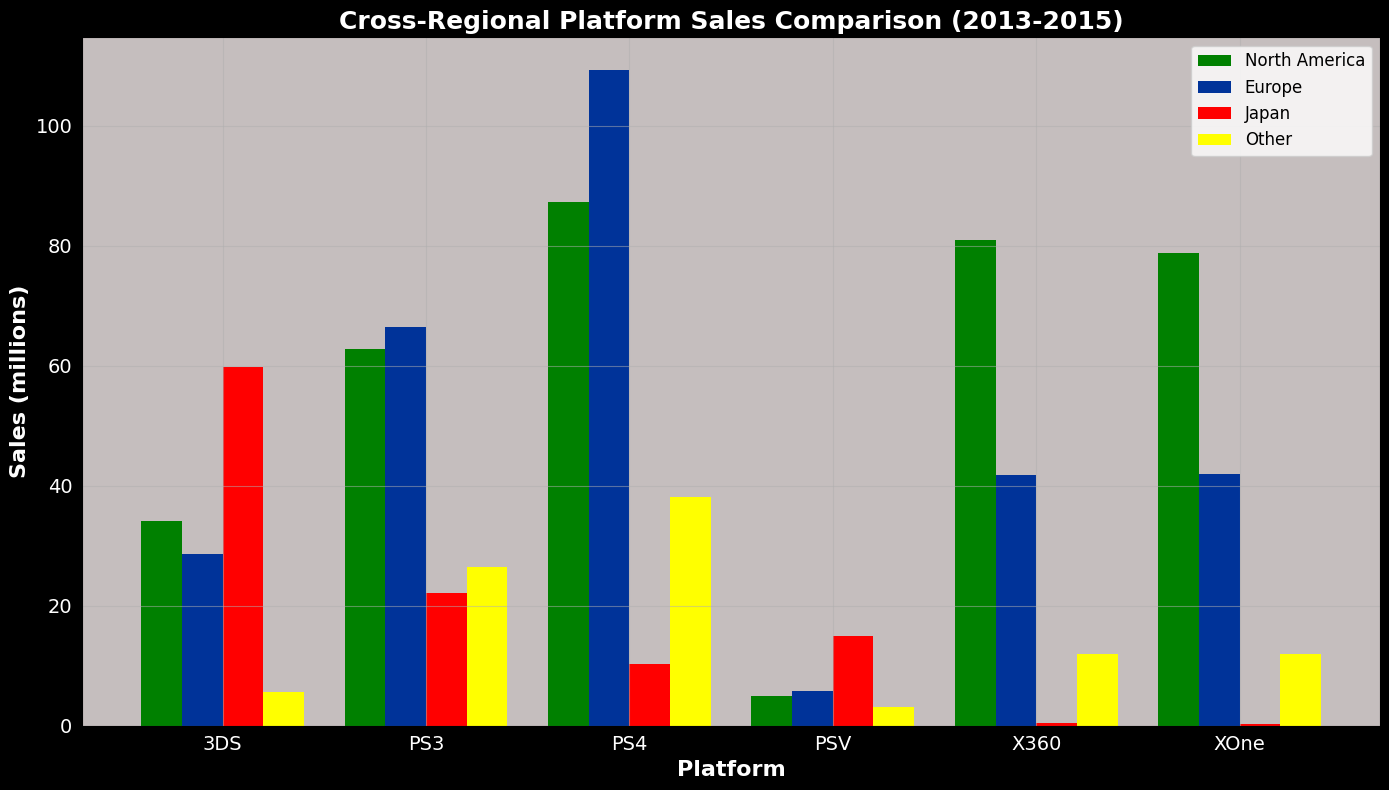

Regional sales by platform:
          na_sales  eu_sales  jp_sales  other_sales
platform                                           
3DS          34.06     28.63     59.78         5.64
PS3          62.83     66.55     22.05        26.40
PS4          87.25    109.31     10.22        38.11
PSV           4.89      5.71     15.03         3.11
X360         80.97     41.81      0.51        11.99
XOne         78.85     41.96      0.33        12.03


In [37]:
selected_platforms = ['PS4', 'PS3', 'X360', 'XOne', '3DS', 'PSV']
platform_filtered_data = games_relevant[games_relevant['platform'].isin(selected_platforms)]
print("Games per platform:")
print(platform_filtered_data['platform'].value_counts())

platform_regional_sales = platform_filtered_data.groupby('platform')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()

plt.figure(figsize=(14, 8), facecolor = 'black')
x = range(len(platform_regional_sales))
width = 0.2

plt.bar([i - 1.5*width for i in x], platform_regional_sales['na_sales'], 
        width, label='North America', color='green')
plt.bar([i - 0.5*width for i in x], platform_regional_sales['eu_sales'], 
        width, label='Europe', color='#003399')
plt.bar([i + 0.5*width for i in x], platform_regional_sales['jp_sales'], 
        width, label='Japan', color='red')
plt.bar([i + 1.5*width for i in x], platform_regional_sales['other_sales'], 
        width, label='Other', color='yellow')

plt.gca().set_facecolor('#c5bebe')
plt.title('Cross-Regional Platform Sales Comparison (2013-2015)', fontsize = 18, color = 'white', fontweight='bold')
plt.xlabel('Platform', fontsize = 16, color = 'white', fontweight='bold')
plt.ylabel('Sales (millions)', fontsize = 16, color = 'white', fontweight='bold')
plt.xticks(x, platform_regional_sales.index, fontsize = 14, color = 'white')
plt.yticks(fontsize = 14, color = 'white')
plt.legend(fontsize = 12,)
plt.tight_layout()
plt.grid(True, alpha = 0.5)
plt.show()

platform_regional_sales = platform_filtered_data.groupby('platform')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()

print("Regional sales by platform:")
print(platform_regional_sales)

## 4.2 Regional Genre Analysis

In [38]:
def analyze_genre_by_region(games_data):
    genre_regional = games_data.groupby('genre')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()
    
    genre_regional['total_sales'] = genre_regional.sum(axis=1)
    genre_regional_sorted = genre_regional.sort_values('total_sales', ascending=False)
    
    top_na = genre_regional.sort_values('na_sales', ascending=False)['na_sales'].head(3)
    top_eu = genre_regional.sort_values('eu_sales', ascending=False)['eu_sales'].head(3)  
    top_jp = genre_regional.sort_values('jp_sales', ascending=False)['jp_sales'].head(3)
    top_other = genre_regional.sort_values('other_sales', ascending=False)['other_sales'].head(3)
    
    return {
        'regional_data': genre_regional_sorted,
        'top_by_region': {
            'NA': top_na,
            'EU': top_eu, 
            'JP': top_jp,
            'Other': top_other
        }
    }
results = analyze_genre_by_region(games_relevant)
print("Complete Genre Regional Analysis:")
print(results['regional_data'])


Complete Genre Regional Analysis:
              na_sales  eu_sales  jp_sales  other_sales  total_sales
genre                                                               
Action          116.76    107.45     33.42        34.13       291.76
Shooter          93.50     71.96      5.55        23.75       194.76
Role-Playing     40.51     32.69     44.43        10.08       127.71
Sports           57.73     48.51      4.49        16.43       127.16
Misc             26.73     19.38      8.16         5.95        60.22
Platform         16.85     14.19      4.68         3.68        39.40
Racing           12.23     18.42      2.29         4.16        37.10
Fighting         13.71      7.21      6.90         3.02        30.84
Simulation        4.70      9.65      4.19         1.33        19.87
Adventure         6.19      6.93      4.64         2.06        19.82
Strategy          3.04      3.63      1.54         0.74         8.95
Puzzle            0.83      0.99      1.18         0.16         3.16


### Cross-Regional Genre Comparison

In [39]:
def calculate_genre_market_share(regional_data):
    regional_sales = regional_data[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']]
    region_totals = regional_sales.sum()
    market_share_percentages = regional_sales.div(region_totals) * 100
    return market_share_percentages.round(2)

genre_market_share = calculate_genre_market_share(results['regional_data'])

print("\n" + "="*43)
print("TOP 5 GENRES BY MARKET SHARE IN EACH REGION")
print("="*43)

regions = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']
region_names = ['North America', 'Europe', 'Japan', 'Other Regions']

for i, (region_col, region_name) in enumerate(zip(regions, region_names)):
    print(f"\n{region_name.upper()}:")
    print("-" * 25)
    top_genres = genre_market_share[region_col].sort_values(ascending=False).head(5)
    
    for rank, (genre, percentage) in enumerate(top_genres.items(), 1):
        print(f"{rank}. {genre}: {percentage}%")


TOP 5 GENRES BY MARKET SHARE IN EACH REGION

NORTH AMERICA:
-------------------------
1. Action: 29.73%
2. Shooter: 23.8%
3. Sports: 14.7%
4. Role-Playing: 10.31%
5. Misc: 6.81%

EUROPE:
-------------------------
1. Action: 31.51%
2. Shooter: 21.1%
3. Sports: 14.23%
4. Role-Playing: 9.59%
5. Misc: 5.68%

JAPAN:
-------------------------
1. Role-Playing: 36.58%
2. Action: 27.51%
3. Misc: 6.72%
4. Fighting: 5.68%
5. Shooter: 4.57%

OTHER REGIONS:
-------------------------
1. Action: 32.35%
2. Shooter: 22.51%
3. Sports: 15.57%
4. Role-Playing: 9.56%
5. Misc: 5.64%


## 4.3 ESRB Rating Impact Analysis

In [40]:
def analyze_rating_by_region(games_relevant):
    rating_regional = games_relevant.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()
    rating_regional['total_sales'] = rating_regional.sum(axis=1)
    rating_regional_sorted = rating_regional.sort_values('total_sales', ascending=False)
    return rating_regional_sorted

rating_results = analyze_rating_by_region(games_relevant)
print("Complete Rating Regional Analysis:")
print(rating_results)

Complete Rating Regional Analysis:
        na_sales  eu_sales  jp_sales  other_sales  total_sales
rating                                                        
M         149.54    128.78     12.91        42.10       333.33
E          71.08     69.75     14.07        19.52       174.42
E10+       50.43     38.88      5.44        11.51       106.26
T          40.84     32.16     18.32        11.18       102.50


In [41]:
def calculate_rating_market_share_by_region(games_relevant):
    rating_regional = games_relevant.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()
    region_totals = rating_regional.sum()
    market_share_by_region = (rating_regional.div(region_totals) * 100).round(2)
    
    return market_share_by_region

rating_market_share = calculate_rating_market_share_by_region(games_relevant)
print("ESRB Rating Market Share by Region (%):")
print(rating_market_share)

def compare_m_vs_e_ratings(games_relevant):
    m_e_games = games_relevant[games_relevant['rating'].isin(['M', 'E'])]
    m_e_regional = m_e_games.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()
    ratios = {}
    regions = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']
    region_names = ['North America', 'Europe', 'Japan', 'Other Regions']
    
    for region, name in zip(regions, region_names):
        m_sales = m_e_regional.loc['M', region]
        e_sales = m_e_regional.loc['E', region]
        ratio = m_sales / e_sales if e_sales > 0 else 0
        ratios[name] = ratio
    
    return ratios, m_e_regional

m_e_ratios, m_e_data = compare_m_vs_e_ratings(games_relevant)
print("\nM-rated to E-rated Sales Ratios by Region:")
for region, ratio in m_e_ratios.items():
    print(f"{region}: {ratio:.2f}:1")

def analyze_avg_sales_by_rating_region(games_relevant):
    # Group by rating and calculate averages
    avg_sales_by_rating = games_relevant.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].agg(['mean', 'count']).round(3)
    
    return avg_sales_by_rating

avg_rating_analysis = analyze_avg_sales_by_rating_region(games_relevant)
print("\nAverage Sales per Game by Rating and Region:")
print(avg_rating_analysis)

ESRB Rating Market Share by Region (%):
        na_sales  eu_sales  jp_sales  other_sales
rating                                           
E          22.79     25.87     27.73        23.15
E10+       16.17     14.42     10.72        13.65
M          47.95     47.77     25.44        49.93
T          13.09     11.93     36.11        13.26

M-rated to E-rated Sales Ratios by Region:
North America: 2.10:1
Europe: 1.85:1
Japan: 0.92:1
Other Regions: 2.16:1

Average Sales per Game by Rating and Region:
       na_sales       eu_sales       jp_sales       other_sales      
           mean count     mean count     mean count        mean count
rating                                                               
E         0.301   236    0.296   236    0.060   236       0.083   236
E10+      0.250   202    0.192   202    0.027   202       0.057   202
M         0.514   291    0.443   291    0.044   291       0.145   291
T         0.165   247    0.130   247    0.074   247       0.045   247


In [42]:
xone_pc = games_relevant[games_relevant['platform'].isin(['XOne', 'PC'])]
xone_pc_with_ratings = xone_pc.dropna(subset=['user_score'])
print(xone_pc_with_ratings.groupby('platform')['user_score'].describe())

pc_ratings = xone_pc_with_ratings[xone_pc_with_ratings['platform'] == 'PC']['user_score']
xone_ratings = xone_pc_with_ratings[xone_pc_with_ratings['platform'] == 'XOne']['user_score']

alpha = 0.05

results = st.ttest_ind(pc_ratings, xone_ratings)
print()
print('T-statistic:', results.statistic)
print('p_value: ',results.pvalue)
print()
if results.pvalue < alpha:
    print('We reject the null hypothesis')
else: 
    print('We cant reject the null hypothesis')


print('=' * 100)

action_sports = games_relevant[games_relevant['genre'].isin(['Action', 'Sports'])]
action_sports_with_ratings = action_sports.dropna(subset=['user_score'])
print(action_sports_with_ratings.groupby('genre')['user_score'].describe())

action_ratings = action_sports_with_ratings[action_sports_with_ratings['genre'] == 'Action']['user_score']
sports_ratings = action_sports_with_ratings[action_sports_with_ratings['genre'] == 'Sports']['user_score']

results2 = st.ttest_ind(action_ratings, sports_ratings)
print()
print('T-statistic:', results2.statistic)
print('P-value:', results2.pvalue)
print()


if results2.pvalue < alpha:
    print('We reject the null hypothesis')
else: 
    print('We cant reject the null hypothesis')

          count      mean       std  min    25%   50%  75%  max
platform                                                       
PC        110.0  6.258182  1.751193  1.4  5.325  6.75  7.6  9.3
XOne      116.0  6.477586  1.288213  2.1  5.775  6.70  7.3  9.2

T-statistic: -1.076751678005444
p_value:  0.28274949832607327

We cant reject the null hypothesis
        count      mean       std  min   25%  50%  75%  max
genre                                                      
Action  304.0  6.893092  1.284762  2.4  6.40  7.2  7.7  9.1
Sports  123.0  5.179675  1.703418  1.4  4.05  5.4  6.3  8.8

T-statistic: 11.310188596740321
P-value: 4.157989291673996e-26

We reject the null hypothesis


For test 1, my null hypothesis assumed that the average user ratings of Xbox One and PC platforms are equal and my alternative hypothesis assumed that the average user ratings of Xbox One and PC platforms are NOT equal. 
The t-test results showed p_value = 0.2827494983260732 meaning I CAN NOT reject the null hypothesis for the platform comparison.

For test 2, my null hypothesis assumed that the average user ratings for action and sports genres were equal and my alternative hypothesis assumed that the average user ratings for action and sports genres are NOT equal.
The t-test results showed p_value = 4.157989291674005e-26 meaning I CAN reject the null hypothesis for the genre comparison.

For both of my hypothesis tests, I chose the independent samples t-test (st.ttest_ind). This was the right choice because I compared the means of two independent groups, Xbox One vs PC platforms (different, unrelated groups) and Action vs Sports genres (different, unrelated groups), and I worked with continuous numerical data (user ratings).
I set alpha = 0.05, which means that I was willing to accept a 5% chance of making a Type I error (rejecting a true null hypothesis). This is the standard threshold in most research because it provides a good balance between being too strict and too lenient. 
Looking at my data for platform comparison, PC (110 games) vs Xbox One (116 games) and genre comparison, Action (304 games) vs Sports (123 games), these sample sizes are adequate for t-tests, especially since I have over 30 observations in each group. I properly handled missing data by using .dropna(subset=['user_score']) to ensures I am only analyzing games that actually have user ratings, making my comparison meaningful.

# General Conclusion

While doing this project, the most important patterns that I discovered were a platform evolution and market shift!

**Key Market Shift:** PS4 and Xbox One emerged as the dominant next-generation platforms. **PS4** showed consistent growth: 26M → 100M → 119M sales (2013-2015) and makes it the **priority platform for 2017 campaigns**, while Xbox One also grew steadily: 19M → 54M → 60M sales and older platforms like PS3 and X360 showed steep declines.
    
**Genre Performance Insights:** Action games had the highest total sales, but declining trend (steep drop from 2013). **Shooter games represent the most reliable investment opportunity** with upward trajectory (1.39M average), Sports & Role-Playing had steady, predictable performance and there was a clear market consolidation around fewer, higher-quality games. 
    
**Regional Strategy Implications:** North America & Europe, who prefer PS4, Xbox platforms and Shooter/Action genres while Japan strongly favors handheld (3DS) and different genre preferences and surprisingly, the rating impact for M-rated games perform differently across regions. 
    
**Quality Focus Trend:** Shifts to where fewer games were released, but had higher average quality scores, games with both critic and user reviews had significantly higher sales, and market moved from quantity (peak years: 1,311 games/year) to quality focus.

**Statistical Analysis Results:** I conducted two hypothesis tests to examine user rating patterns. The first test compared average user ratings between Xbox One and PC platforms, while the second test examined whether Action and Sports games have equal average user ratings.

Statistical analysis confirms with 95% confidence that **different platforms have very similar user ratings**, suggesting platform choice doesn't significantly impact game quality perception. However, there is a **significant difference in user ratings between Action and Sports genres**, which aligns with expectations since different game genres appeal to different player preferences and have varying quality standards. Specifically, Action games averaged significantly higher user ratings (6.89) compared to Sports games (5.18), with this 1.7-point difference being highly statistically significant (p < 0.001).

### Priority Rankings for 2017 Strategy

**#1 Priority: PS4 Shooter Games for NA/EU Markets**
Statistical evidence shows that PS4 showed 358% growth (26M → 119M sales) and Shooter genre demonstrates consistent upward trajectory (1.39M average). **With 95% confidence, we can conclude** that this combination offers maximum ROI (Return on Investment)!

**#2 Priority: Cross-platform Action Games**
Despite declining trend, Action maintains highest total sales and strong performance across all regions except Japan.

**#3 Priority: Sports Games for Consistent Revenue**
Steady, predictable performance provides reliable baseline revenue!

### Limitations and Risk Considerations

**Data Limitations:**
While 2016 data shows some volatility (efficiency dropped to 0.26), the 2013-2015 trends provide a solid foundation for 2017 planning but missing review data for 46% of games may impact quality assessments.**Market Risks:**
Action genre's declining trajectory requires monitoring while regional preferences vary significantly (Japan favors handhelds vs. consoles).